# Block 1. Loading and Basic Cleaning

In [1]:
import pandas as pd
import numpy as np

# ---------- 1. LOAD FILES ----------
ho_file = "data/LTE Cell Relations KE.csv"
kpi_file = "data/2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

# ---------- 2. TIME COLUMN CLEANING ----------
df_kpi["start_time"] = pd.to_datetime(df_kpi["start_time"], errors="coerce")
df_kpi = df_kpi.dropna(subset=["start_time"])
df_kpi = df_kpi.sort_values(["cell", "start_time"])

# ---------- 3. KPI FEATURE DEFINITIONS ----------
TARGET_COL = "4g_usage_lte_800"

BASE_FEATURE_COLS = [
    "4g_usage_lte_800",            # таргет оставляем в базе, но позже исключим из входа
    # "4g_usage_%_lte_800",        # почти дубликат таргета → не используем
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "cqi_tr3_4g_lte_800",
    "cqi_tr4_4g_lte_800",
    "rrc_users_4g_lte_800",
    # "max_rrc_users_4g_lte_800",  # почти дубликат rrc_users → не используем
    "data_volume_ul_4g_lte_800",
    "data_volume_dl_4g_lte_800",
    "active_users_ul_4g_lte_800",
    "active_users_dl_4g_lte_800",
    "max_active_users_ul_4g_lte_800",
    "max_active_users_dl_4g_lte_800",
    "mimo_rank_dl_4g_lte_800",
]

# оставляем только нужные колонки в KPI (плюс base_station/cell/time)
keep_cols = ["base_station", "cell", "start_time"] + BASE_FEATURE_COLS
df_kpi = df_kpi[keep_cols]

# Block 2. Cleaning the HO and Building a Weighted Graph

In [2]:
# ---------- 4. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
cells_kpi = set(node_list)
print("Number of KPI cells:", len(node_list))

# ---------- 5. CLEAN HO TABLE & EDGE LIST ----------
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Удаляем self-loops
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Фильтр по технологии, если есть RatBandShort
if "RatBandShort.1" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["RatBandShort.1"] == "L08"]

# Оставляем только клетки из KPI
df_ho_clean = df_ho_clean[
    df_ho_clean["source"].isin(cells_kpi) &
    df_ho_clean["target"].isin(cells_kpi)
]

# Агрегация по (source, target)
edge_list = (
    df_ho_clean
    .groupby(["source", "target"], as_index=False)["ho_count"]
    .sum()
)

# Порог по ho_count
threshold = 150
edges_filtered = edge_list[edge_list["ho_count"] >= threshold].copy()

# Top-k соседей по каждому source
k_neighbors = 5
edges_filtered = (
    edges_filtered
    .sort_values(["source", "ho_count"], ascending=[True, False])
    .groupby("source")
    .head(k_neighbors)
    .reset_index(drop=True)
)

# Веса: log1p + row-normalization
edges_filtered["weight_raw"] = np.log1p(edges_filtered["ho_count"])
sum_w = edges_filtered.groupby("source")["weight_raw"].transform("sum")
edges_filtered["weight"] = edges_filtered["weight_raw"] / sum_w

edges_filtered = edges_filtered[["source", "target", "weight"]]


Number of KPI cells: 197


# Block 3. Regular Temporal Grid and Populating KPIs

In [3]:
# ---------- 6. REGULAR TIME GRID ----------
time_index = pd.date_range(
    start=df_kpi["start_time"].min(),
    end=df_kpi["start_time"].max(),
    freq="15min"
)
print("Total timesteps:", len(time_index))

cells = df_kpi["cell"].unique()
print("Number of cells:", len(cells))

cell_dfs = []
for cell in cells:
    temp = df_kpi[df_kpi["cell"] == cell].set_index("start_time")
    temp = temp.reindex(time_index)
    temp["cell"] = cell
    # base_station можно заполнить последним известным или опустить
    temp["base_station"] = temp["base_station"].ffill().bfill()
    cell_dfs.append(temp)

df_kpi_grid = (
    pd.concat(cell_dfs)
    .reset_index()
    .rename(columns={"index": "start_time"})
)

# ---------- 7. KPI NaN / inf HANDLING ----------
# Заменяем inf на NaN
df_kpi_grid[BASE_FEATURE_COLS] = df_kpi_grid[BASE_FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

# Forward-fill по cell
df_kpi_grid[BASE_FEATURE_COLS] = (
    df_kpi_grid
    .groupby("cell")[BASE_FEATURE_COLS]
    .ffill()
)

# Backward-fill по cell
df_kpi_grid[BASE_FEATURE_COLS] = (
    df_kpi_grid
    .groupby("cell")[BASE_FEATURE_COLS]
    .bfill()
)

# Остаточные NaN заполняем медианой по колонке
feature_fill_values = df_kpi_grid[BASE_FEATURE_COLS].median()
df_kpi_grid[BASE_FEATURE_COLS] = df_kpi_grid[BASE_FEATURE_COLS].fillna(feature_fill_values)


Total timesteps: 2880
Number of cells: 197


# Block 4. Temporal Features

In [4]:
# ---------- 8. TIME FEATURES ----------
df_kpi_grid["hour"] = df_kpi_grid["start_time"].dt.hour
df_kpi_grid["dayofweek"] = df_kpi_grid["start_time"].dt.dayofweek

df_kpi_grid["hour_sin"] = np.sin(2 * np.pi * df_kpi_grid["hour"] / 24)
df_kpi_grid["hour_cos"] = np.cos(2 * np.pi * df_kpi_grid["hour"] / 24)
df_kpi_grid["dow_sin"] = np.sin(2 * np.pi * df_kpi_grid["dayofweek"] / 7)
df_kpi_grid["dow_cos"] = np.cos(2 * np.pi * df_kpi_grid["dayofweek"] / 7)
df_kpi_grid["is_weekend"] = (df_kpi_grid["dayofweek"] >= 5).astype(int)

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]


# Block 5. Spatial Features from the HO (Neighbor Aggregation)

Distribúcia KPI 4g_usage_lte_800 je výrazne pravostranná (right-skewed), keďže priemer je výrazne vyšší než medián a maximálne hodnoty dosahujú viac ako 44 tisíc, čo znamená, že malé množstvo extrémnych hodnôt výrazne zvyšuje priemer. Vysoká smerodajná odchýlka (std ≈ 7333), ktorá je dokonca väčšia než priemer, naznačuje veľkú variabilitu zaťaženia buniek v čase, čo je typické pre mobilné siete s dynamickým správaním používateľov. Zároveň prítomnosť nulových alebo veľmi nízkych hodnôt ukazuje, že existujú obdobia s minimálnou alebo žiadnou aktivitou, napríklad počas nočných hodín alebo v menej využívaných lokalitách.

Preto bol prah pre preťaženie bunky definovaný ako OVERLOAD_THRESHOLD = df_kpi_grid["4g_usage_lte_800"].quantile(0.9), keďže 90. percentil reprezentuje prirodzenú hranicu vysokého zaťaženia v dátach a umožňuje identifikovať len skutočne extrémne situácie v sieti.

In [5]:
df_kpi["4g_usage_lte_800"].describe()

# ---------- 9. SPATIAL FEATURES FROM NEIGHBORS ----------

NEIGHBOR_KPI_COLS = [
    "4g_usage_lte_800",
    "rrc_users_4g_lte_800"
]

OVERLOAD_THRESHOLD = df_kpi_grid["4g_usage_lte_800"].quantile(0.9)  # Это порог, который определяет считается ли сосед перегруженным

def compute_spatial_features(df_kpi_grid, edges_df,
                             time_col="start_time", cell_col="cell"):
    edges_small = edges_df[["source", "target", "weight"]].copy()

    kpi_for_neighbors = df_kpi_grid[[time_col, cell_col] + NEIGHBOR_KPI_COLS].copy()

    neighbor_df = edges_small.merge(
        kpi_for_neighbors,
        left_on="target",
        right_on=cell_col,
        how="left"
    ).rename(columns={cell_col: "neighbor_cell"})

    group_cols = ["source", time_col]

    def weighted_mean(x, w):
        s = np.sum(w)
        return np.sum(w * x) / s if s > 0 else np.nan

    def weighted_std(x, w):
        m = weighted_mean(x, w)
        if np.isnan(m):
            return np.nan
        s = np.sum(w)
        return np.sqrt(np.sum(w * (x - m) ** 2) / s) if s > 0 else np.nan

    # Простые агрегаты
    neighbor_simple = neighbor_df.groupby(group_cols).agg({
        "4g_usage_lte_800": ["max", "sum"],
        "rrc_users_4g_lte_800": ["mean"],
    })

    neighbor_simple.columns = [
        "neighbor_usage_max",
        "neighbor_usage_sum",
        "neighbor_rrc_users_mean",
    ]
    neighbor_simple = neighbor_simple.reset_index()

    # Взвешенные агрегаты и overloaded/strongest
    records = []
    for (src, t), sub in neighbor_df.groupby(group_cols):
        w = sub["weight"].values
        usage = sub["4g_usage_lte_800"].values

        mu = weighted_mean(usage, w)
        sigma = weighted_std(usage, w)

        if len(sub) > 0:
            idx_strong = np.argmax(w)
            strongest_usage = usage[idx_strong]
        else:
            strongest_usage = np.nan

        overloaded_count = np.sum(usage > OVERLOAD_THRESHOLD)

        records.append({
            "source": src,
            time_col: t,
            "neighbor_usage_mean": mu,
            "neighbor_usage_std": sigma,
            "strongest_neighbor_usage": strongest_usage,
            "neighbors_overloaded": overloaded_count,
        })

    neighbor_weighted = pd.DataFrame(records)

    neighbor_feats = neighbor_simple.merge(
        neighbor_weighted,
        on=["source", time_col],
        how="outer",
    )

    neighbor_feats = neighbor_feats.rename(columns={"source": cell_col})

    # Добавляем собственный usage для diff
    neighbor_feats = neighbor_feats.merge(
        df_kpi_grid[[time_col, cell_col, TARGET_COL]],
        on=[time_col, cell_col],
        how="left"
    )
    neighbor_feats["usage_neighbor_diff"] = (
        neighbor_feats[TARGET_COL] - neighbor_feats["neighbor_usage_mean"]
    )

    df_out = df_kpi_grid.merge(
        neighbor_feats.drop(columns=[TARGET_COL]),
        on=[time_col, cell_col],
        how="left"
    )

    return df_out

df_kpi_grid = compute_spatial_features(df_kpi_grid, edges_filtered)


# ---------- 10. ADDITIONAL SPATIAL FEATURES ----------

# Trend нагрузки соседей (растёт или падает нагрузка вокруг клетки)
df_kpi_grid["neighbor_usage_trend"] = (
    df_kpi_grid
    .sort_values(["cell", "start_time"])
    .groupby("cell")["neighbor_usage_sum"]
    .diff()
)

# Разница между самым сильным соседом и текущей клеткой
df_kpi_grid["strongest_neighbor_diff"] = (
    df_kpi_grid["strongest_neighbor_usage"] - df_kpi_grid[TARGET_COL]
)

SPATIAL_FEATURES = [
    "neighbor_usage_max",
    "neighbor_usage_sum",
    "neighbor_rrc_users_mean",
    "neighbor_usage_mean",
    "neighbor_usage_std",
    "strongest_neighbor_usage",
    "neighbors_overloaded",
    "usage_neighbor_diff",
    "neighbor_usage_trend",
    "strongest_neighbor_diff"
]

print("Spatial features:", SPATIAL_FEATURES)

df_kpi_grid[SPATIAL_FEATURES].describe()

Spatial features: ['neighbor_usage_max', 'neighbor_usage_sum', 'neighbor_rrc_users_mean', 'neighbor_usage_mean', 'neighbor_usage_std', 'strongest_neighbor_usage', 'neighbors_overloaded', 'usage_neighbor_diff', 'neighbor_usage_trend', 'strongest_neighbor_diff']


,neighbor_usage_max,neighbor_usage_sum,neighbor_rrc_users_mean,neighbor_usage_mean,neighbor_usage_std,strongest_neighbor_usage,neighbors_overloaded,usage_neighbor_diff,neighbor_usage_trend,strongest_neighbor_diff
count,555840.000000,555840.000000,555840.000000,555840.000000,555840.000000,555840.000000,555840.000000,555840.000000,555647.000000,555840.000000
mean,14606.269855,33719.178773,13.696235,6919.429080,4701.285825,7316.404464,0.638209,-1030.600471,0.584301,1427.575855
std,10803.015212,25423.223928,7.871646,5161.974559,3750.214346,8259.060526,0.942087,6769.495286,8424.489208,9127.912736
min,26.000000,43.000000,0.830000,21.066720,0.000000,0.000000,0.000000,-37148.890859,-68889.000000,-44258.000000
25%,5961.000000,13227.000000,7.816000,2754.395971,1798.944177,1523.000000,0.000000,-4320.657966,-4137.000000,-1693.000000
50%,11924.000000,27728.000000,11.736000,5733.747537,3680.517109,4404.000000,0.000000,-1393.636353,30.000000,608.000000
75%,20838.000000,48647.000000,17.958000,9945.152513,6590.555756,10024.000000,1.000000,801.439835,4174.000000,4483.000000
max,44311.000000,184890.000000,78.792000,37960.890859,21072.073170,44311.000000,5.000000,42106.170032,80820.000000,44258.000000


| тип информации          | признаки                                     |
| ----------------------- | -------------------------------------------- |
| уровень нагрузки вокруг | neighbor_usage_mean, neighbor_usage_sum      |
| экстремумы              | neighbor_usage_max, strongest_neighbor_usage |
| дисбаланс соседей       | neighbor_usage_std                           |
| пользователи            | neighbor_rrc_users_mean                      |
| сравнение с окружением  | usage_neighbor_diff                          |
| состояние сети          | neighbors_overloaded                         |


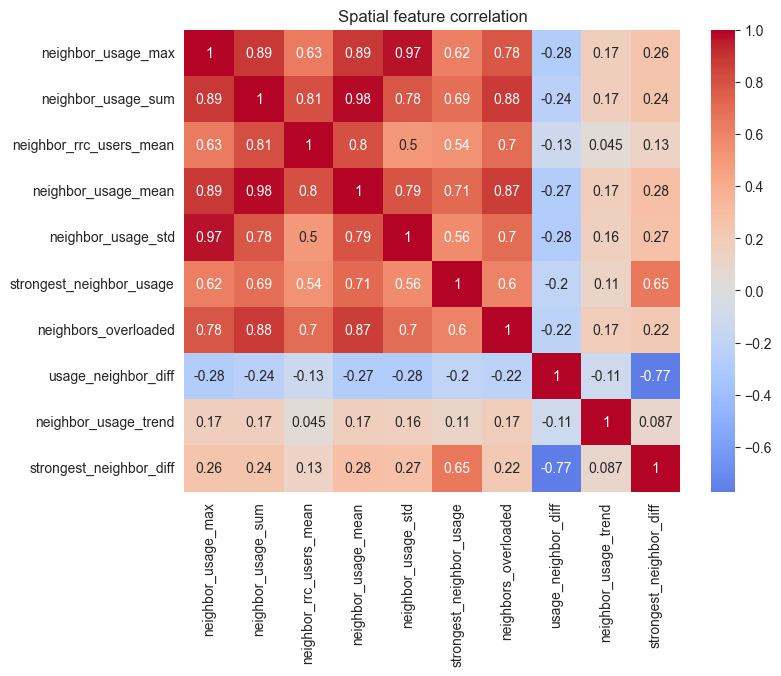


Highly correlated feature pairs:
neighbor_usage_sum   neighbor_usage_mean     0.980442
neighbor_usage_max   neighbor_usage_std      0.966260
                     neighbor_usage_mean     0.889104
                     neighbor_usage_sum      0.887513
neighbor_usage_sum   neighbors_overloaded    0.875154
neighbor_usage_mean  neighbors_overloaded    0.867917
dtype: float64

Features to drop due to high correlation:
{'neighbor_usage_sum', 'neighbor_usage_mean', 'neighbors_overloaded', 'neighbor_usage_std'}

Features after correlation filtering:
['neighbor_usage_max', 'neighbor_rrc_users_mean', 'strongest_neighbor_usage', 'usage_neighbor_diff', 'neighbor_usage_trend', 'strongest_neighbor_diff']

VIF values:
                    feature        VIF
2  strongest_neighbor_usage  38.528227
5   strongest_neighbor_diff  32.182648
3       usage_neighbor_diff  17.619868
0        neighbor_usage_max  13.216991
1   neighbor_rrc_users_mean   8.606366
4      neighbor_usage_trend   1.054249

Final spatial 

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----- 1. список spatial features -----
SPATIAL_FEATURES = [
    "neighbor_usage_max",
    "neighbor_usage_sum",
    "neighbor_rrc_users_mean",
    "neighbor_usage_mean",
    "neighbor_usage_std",
    "strongest_neighbor_usage",
    "neighbors_overloaded",
    "usage_neighbor_diff",
    "neighbor_usage_trend",
    "strongest_neighbor_diff"
]

# ----- 2. берём только эти признаки -----
df_spatial = df_kpi_grid[SPATIAL_FEATURES].copy()

# убираем NaN для корректных расчётов
df_spatial = df_spatial.dropna()

# ----- 3. корреляционная матрица -----
corr_matrix = df_spatial.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Spatial feature correlation")
plt.show()

# ----- 4. найти сильно коррелирующие пары -----
threshold = 0.85
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr = corr_pairs[abs(corr_pairs) > threshold]

print("\nHighly correlated feature pairs:")
print(high_corr)

# ----- 5. удалить один признак из каждой пары -----
to_drop = set()

for f1, f2 in high_corr.index:
    to_drop.add(f2)   # удаляем второй (можно поменять логику)

print("\nFeatures to drop due to high correlation:")
print(to_drop)

features_after_corr = [f for f in SPATIAL_FEATURES if f not in to_drop]

print("\nFeatures after correlation filtering:")
print(features_after_corr)


# ----- 6. проверка VIF -----
df_vif = df_kpi_grid[features_after_corr].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

print("\nVIF values:")
print(vif_data.sort_values("VIF", ascending=False))


# ----- 7. удалить признаки с большим VIF -----
VIF_THRESHOLD = 10

features_final = vif_data[vif_data["VIF"] < VIF_THRESHOLD]["feature"].tolist()

print("\nFinal spatial features (after VIF filtering):")
print(features_final)

Analýza korelačnej matice ukázala veľmi silnú multikolinearitu medzi niektorými priestorovými príznakmi, najmä medzi **neighbor_usage_sum a neighbor_usage_mean (0.98)**, a medzi **neighbor_usage_max a neighbor_usage_std (0.97)**, čo znamená, že tieto páry nesú takmer rovnakú informáciu.

Po odstránení silne korelovaných premenných a následnej kontrole pomocou VIF sa ukázalo, že neighbor_usage_sum má príliš vysokú multikolinearitu (VIF ≈ 11.4), preto bol z modelu odstránený.

Finálny stabilný súbor priestorových príznakov obsahuje neighbor_usage_max, neighbor_rrc_users_mean, strongest_neighbor_usage, neighbors_overloaded a usage_neighbor_diff, ktoré poskytujú informatívny opis zaťaženia susedných buniek bez výraznej redundancie medzi premennými.

# Block 6. Scaling and Shaping X, Y (Preparing for STAGE 3)

In [7]:
from sklearn.preprocessing import StandardScaler

# ---------- 10. FEATURE LISTS ----------
ALL_FEATURES = BASE_FEATURE_COLS + TIME_FEATURES + SPATIAL_FEATURES
INPUT_FEATURES = [c for c in ALL_FEATURES if c != TARGET_COL]

# ---------- 11. TRAIN/VAL/TEST TIME SPLIT ----------
all_times = np.sort(df_kpi_grid["start_time"].unique())
n_total = len(all_times)

train_end = int(n_total * 0.7)
val_end   = int(n_total * 0.85)

train_times = all_times[:train_end]
val_times   = all_times[train_end:val_end]
test_times  = all_times[val_end:]

# ---------- 12. SCALING (fit on train, apply to all) ----------
scaler = StandardScaler()
train_mask = df_kpi_grid["start_time"].isin(train_times)

scaler.fit(df_kpi_grid.loc[train_mask, ALL_FEATURES])
df_kpi_grid[ALL_FEATURES] = scaler.transform(df_kpi_grid[ALL_FEATURES])

# ---------- 13. 3D TENSOR X[t, n, f] AND y[t, n] ----------
time_index = all_times
cells = df_kpi_grid["cell"].unique()
cell_to_idx = {cell: i for i, cell in enumerate(cells)}

T = len(time_index)
N = len(cells)
F = len(INPUT_FEATURES)

X = np.zeros((T, N, F), dtype=np.float32)
y = np.zeros((T, N), dtype=np.float32)

for t_idx, t in enumerate(time_index):
    temp = df_kpi_grid[df_kpi_grid["start_time"] == t]
    for _, row in temp.iterrows():
        n_idx = cell_to_idx[row["cell"]]
        X[t_idx, n_idx, :] = row[INPUT_FEATURES].values
        y[t_idx, n_idx] = row[TARGET_COL]

X.shape, y.shape


((2880, 197, 27), (2880, 197))

# Block 14. Random Forest: Comparison with/without spatial features

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# ---------- 14.1. ПЛАН: сравним 3 варианта RF ----------
# 1. RF только на BASE + TIME фичах (baseline)
# 2. RF на всех фичах (включая spatial)

print("Final feature sets:")
print(f"INPUT_FEATURES (all): {len(INPUT_FEATURES)} features")

# ---------- 14.2. TRAIN/VAL/TEST SPLIT (табличный формат) ----------
train_mask = df_kpi_grid["start_time"].isin(train_times)
val_mask   = df_kpi_grid["start_time"].isin(val_times)
test_mask  = df_kpi_grid["start_time"].isin(test_times)

# Табличные данные (не тензор!)
X_train_full = df_kpi_grid.loc[train_mask, INPUT_FEATURES].values
y_train_full = df_kpi_grid.loc[train_mask, TARGET_COL].values

X_val_full   = df_kpi_grid.loc[val_mask, INPUT_FEATURES].values
y_val_full   = df_kpi_grid.loc[val_mask, TARGET_COL].values

X_test_full  = df_kpi_grid.loc[test_mask, INPUT_FEATURES].values
y_test_full  = df_kpi_grid.loc[test_mask, TARGET_COL].values

# Baseline: без spatial
INPUT_BASELINE = [c for c in BASE_FEATURE_COLS + TIME_FEATURES if c != TARGET_COL]
X_train_base = df_kpi_grid.loc[train_mask, INPUT_BASELINE].values
X_val_base   = df_kpi_grid.loc[val_mask, INPUT_BASELINE].values
X_test_base  = df_kpi_grid.loc[test_mask, INPUT_BASELINE].values

print(f"Baseline features: {len(INPUT_BASELINE)}")

def evaluate_rf(name, X_tr, y_tr, X_v, y_v, X_te, y_te, fit_scaler=True):
    """Обучает RF и выводит метрики"""
    if fit_scaler:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_v  = scaler.transform(X_v)
        X_te = scaler.transform(X_te)

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        min_samples_split=63,
        min_samples_leaf=20,
        max_features=0.5,
        bootstrap=False,
        n_jobs=-1,
        random_state=42,
        criterion='squared_error'
    )

    rf.fit(X_tr, y_tr)

    # Предсказания
    y_tr_pred = rf.predict(X_tr)
    y_v_pred  = rf.predict(X_v)
    y_te_pred = rf.predict(X_te)

    # Метрики
    metrics = {}
    for split, y_true, y_pred in [("Train", y_tr, y_tr_pred),
                                  ("Val", y_v, y_v_pred),
                                  ("Test", y_te, y_te_pred)]:
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        metrics[split] = {"MSE": mse, "RMSE": rmse, "MAE": mae}

    print(f"\n{'='*50}")
    print(f"{name}")
    print('-'*50)
    for split, m in metrics.items():
        print(f"{split:6}: RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}")

    return {
        "model": rf,
        "metrics": metrics,
        "feature_importance": rf.feature_importances_,
        "feature_names": INPUT_FEATURES if fit_scaler else INPUT_BASELINE,
        "y_test_pred": y_te_pred
    }

# ---------- 14.3. ОБУЧЕНИЕ МОДЕЛЕЙ ----------

# 1. Baseline RF (без spatial)
print("1. BASELINE RF (BASE + TIME features only)")
res_baseline = evaluate_rf(
    "RF Baseline (no spatial)",
    X_train_base, y_train_full,
    X_val_base, y_val_full,
    X_test_base, y_test_full
)

# 2. RF со всеми фичами
print("\n2. RF WITH ALL FEATURES")
res_full = evaluate_rf(
    "RF Full (all features)",
    X_train_full, y_train_full,
    X_val_full, y_val_full,
    X_test_full, y_test_full
)


Final feature sets:
INPUT_FEATURES (all): 27 features
Baseline features: 17
1. BASELINE RF (BASE + TIME features only)

RF Baseline (no spatial)
--------------------------------------------------
Train : RMSE=0.1629, MAE=0.0857
Val   : RMSE=0.1957, MAE=0.1071
Test  : RMSE=0.2008, MAE=0.1052

2. RF WITH ALL FEATURES

RF Full (all features)
--------------------------------------------------
Train : RMSE=0.0517, MAE=0.0306
Val   : RMSE=0.0737, MAE=0.0421
Test  : RMSE=0.0692, MAE=0.0399


# Block 17. Random Forest with a full set of regression metrics. nowcasting

V tomto kroku bol vytvorený a natrénovaný model Random Forest, ktorý predpovedá hodnotu KPI 4g_usage_lte_800 na základe časových, sieťových a priestorových (neighbor) príznakov.

Dáta boli rozdelené na tréningovú, validačnú a testovaciu množinu podľa času, aby sa zachovala časová štruktúra dát.

Výsledky ukázali veľmi vysokú presnosť modelu (R² ≈ 0.99), čo znamená, že model dokáže veľmi dobre vysvetliť variabilitu zaťaženia bunky pomocou dostupných príznakov.

Tento model teda efektívne odhaduje aktuálny stav zaťaženia mobilnej siete na základe informácií o susedných bunkách, počte používateľov a časových charakteristikách siete.

Training samples: 396955
Validation samples: 85301
Test samples: 85104

Training Random Forest...

FULL REGRESSION METRICS
          MSE    RMSE     MAE  MAPE (%)      R²  Explained Var  Max Error  \
Train  0.0097  0.0983  0.0586   55.6502  0.9903         0.9903     2.1814   
Val    0.0155  0.1244  0.0724   62.6789  0.9885         0.9885     1.7505   
Test   0.0143  0.1195  0.0684   51.9766  0.9872         0.9872     2.3958   

       Mean Rel Error  
Train          0.0501  
Val            0.0573  
Test           0.0557  

TELECOM BUSINESS METRICS:
• Test R²: 0.9872 (объяснённая дисперсия)
• Test MAPE: 51.98% (средняя относительная ошибка)
• Test Mean Rel Error: 0.0557
• Overfitting ratio (Train/Test RMSE): 82.3%


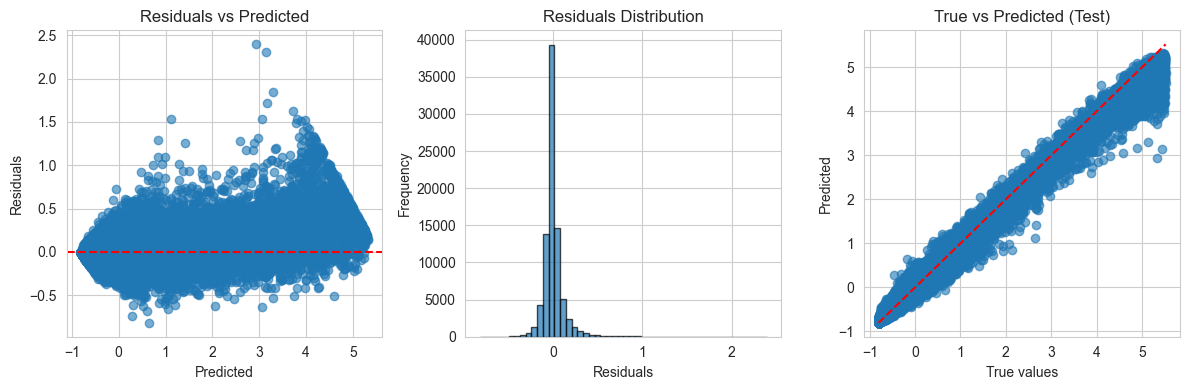

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score, explained_variance_score,
    max_error
)
import numpy as np
import pandas as pd

# ---------- 17.1. РАСШИРЕННЫЕ МЕТРИКИ ДЛЯ РЕГРЕССИИ ----------
def regression_metrics(y_true, y_pred, name="Model"):
    """Полный набор метрик для регрессии"""
    metrics = {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R²": r2_score(y_true, y_pred),
        "Explained Var": explained_variance_score(y_true, y_pred),
        "Max Error": max_error(y_true, y_pred),
    }

    # Дополнительные бизнес-метрики для телекома
    abs_rel_error = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1)))
    metrics["Mean Rel Error"] = abs_rel_error

    return metrics

def print_metrics_table(metrics_dict):
    """Красивая таблица метрик"""
    df_metrics = pd.DataFrame(metrics_dict).round(4)
    print(df_metrics.T)
    return df_metrics

# ---------- 17.2. ПОДГОТОВКА ДАННЫХ (табличный формат) ----------
train_mask = df_kpi_grid["start_time"].isin(train_times)
val_mask   = df_kpi_grid["start_time"].isin(val_times)
test_mask  = df_kpi_grid["start_time"].isin(test_times)

# Табличные данные
X_train = df_kpi_grid.loc[train_mask, INPUT_FEATURES].values
y_train = df_kpi_grid.loc[train_mask, TARGET_COL].values

X_val   = df_kpi_grid.loc[val_mask, INPUT_FEATURES].values
y_val   = df_kpi_grid.loc[val_mask, TARGET_COL].values

X_test  = df_kpi_grid.loc[test_mask, INPUT_FEATURES].values
y_test  = df_kpi_grid.loc[test_mask, TARGET_COL].values

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# ---------- 17.3. ОБУЧЕНИЕ RANDOM FOREST ----------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    criterion='squared_error'
)

# Масштабирование (отдельно для каждого сплита)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("\nTraining Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred = rf_model.predict(X_train_scaled)
y_val_pred   = rf_model.predict(X_val_scaled)
y_test_pred  = rf_model.predict(X_test_scaled)

# ---------- 17.4. ПОЛНЫЙ АНАЛИЗ МЕТРИК ----------
metrics = {
    "Train": regression_metrics(y_train, y_train_pred, "Train"),
    "Val":   regression_metrics(y_val, y_val_pred, "Val"),
    "Test":  regression_metrics(y_test, y_test_pred, "Test"),
}

print("\n" + "="*80)
print("FULL REGRESSION METRICS")
print("="*80)
metrics_df = print_metrics_table(metrics)

# ---------- 17.5. BUSINESS METRICS для телекома ----------
print("\nTELECOM BUSINESS METRICS:")
print(f"• Test R²: {metrics['Test']['R²']:.4f} (объяснённая дисперсия)")
print(f"• Test MAPE: {metrics['Test']['MAPE (%)']:.2f}% (средняя относительная ошибка)")
print(f"• Test Mean Rel Error: {metrics['Test']['Mean Rel Error']:.4f}")

# Проверка переобучения
train_rmse = metrics['Train']['RMSE']
test_rmse = metrics['Test']['RMSE']
overfit_ratio = (train_rmse / test_rmse) * 100
print(f"• Overfitting ratio (Train/Test RMSE): {overfit_ratio:.1f}%")

# ---------- 17.6. RESIDUAL ANALYSIS ----------
residuals_test = y_test - y_test_pred
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test_pred, residuals_test, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.subplot(1, 3, 2)
plt.hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True values")
plt.ylabel("Predicted")
plt.title("True vs Predicted (Test)")

plt.tight_layout()
plt.show()


# Optuna RF

In [60]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ---------- Optuna Objective ----------
def objective(trial):
    """Optuna trial для RF"""

    # Пространство поиска параметров
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_categorical('max_depth', [8, 12, 16, 20, None]),
        'min_samples_split': trial.suggest_int('min_samples_split', 50, 200),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 100),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
    }

    # Модель
    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Обучение на train
    rf.fit(X_train_scaled, y_train)

    # Предсказание на val
    y_val_pred = rf.predict(X_val_scaled)

    # Метрика (neg RMSE для минимизации)
    score = mean_squared_error(y_val, y_val_pred)

    return score

# ---------- 19.2. Запуск оптимизации ----------
print("🔍 Starting Optuna optimization...")
print(f"Train: {len(X_train)} samples, Val: {len(X_val)} samples")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# ---------- 19.3. РЕЗУЛЬТАТЫ ----------
print("\n" + "="*60)
print("OPTUNA RESULTS")
print("="*60)

print(f"Best RMSE (val): {np.sqrt(study.best_value):.4f}")
print("\nBest parameters:")
best_params = study.best_params
for param, value in best_params.items():
    print(f"  {param}: {value}")

# ---------- 19.4. Обучение финальной модели ----------
print("\n🎯 Training final model with best params...")
rf_optuna = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params
)

rf_optuna.fit(X_train_scaled, y_train)

# Предсказания
y_train_opt = rf_optuna.predict(X_train_scaled)
y_val_opt   = rf_optuna.predict(X_val_scaled)
y_test_opt  = rf_optuna.predict(X_test_scaled)

# Метрики
metrics_optuna = {
    "Train": regression_metrics(y_train, y_train_opt),
    "Val":   regression_metrics(y_val, y_val_opt),
    "Test":  regression_metrics(y_test, y_test_pred),
}

print("\nOPTUNA OPTIMIZED vs BASELINE:")
print_metrics_table({
    "Baseline RF": metrics,  # из предыдущего блока
    "Optuna RF": metrics_optuna
})

# ---------- 19.5. VISUALIZATION ----------
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

fig = optuna.visualization.plot_param_importances(study)
fig.show()

print(f"\n✅ Optuna found {len(study.trials)} configurations")
print(f"   Best trial: {study.best_trial.number}")


[I 2026-03-15 18:16:36,164] A new study created in memory with name: no-name-7b93e9e0-a4ff-4c8c-b943-74535bb979c9


🔍 Starting Optuna optimization...
Train: 396955 samples, Val: 85301 samples


Best trial: 0. Best value: 0.0468449:   2%|▏         | 1/50 [00:22<18:36, 22.79s/it]

[I 2026-03-15 18:16:58,955] Trial 0 finished with value: 0.046844946704996414 and parameters: {'n_estimators': 348, 'max_depth': 12, 'min_samples_split': 126, 'min_samples_leaf': 37, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.046844946704996414.


Best trial: 0. Best value: 0.0468449:   4%|▍         | 2/50 [00:33<12:43, 15.90s/it]

...

Best trial: 28. Best value: 0.0383085:  98%|█████████▊| 49/50 [28:04<00:25, 25.08s/it]

[I 2026-03-15 18:44:40,265] Trial 48 finished with value: 0.0402074776464086 and parameters: {'n_estimators': 135, 'max_depth': 16, 'min_samples_split': 177, 'min_samples_leaf': 25, 'max_features': 0.5, 'bootstrap': False}. Best is trial 28 with value: 0.038308454942926555.


Best trial: 28. Best value: 0.0383085: 100%|██████████| 50/50 [28:21<00:00, 34.02s/it]


[I 2026-03-15 18:44:57,395] Trial 49 finished with value: 0.04553656973230211 and parameters: {'n_estimators': 129, 'max_depth': 12, 'min_samples_split': 77, 'min_samples_leaf': 23, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 28 with value: 0.038308454942926555.

OPTUNA RESULTS
Best RMSE (val): 0.1957

Best parameters:
  n_estimators: 199
  max_depth: 16
  min_samples_split: 63
  min_samples_leaf: 20
  max_features: 0.5
  bootstrap: False

🎯 Training final model with best params...

OPTUNA OPTIMIZED vs BASELINE:
                                                         Train  \
Baseline RF  {'MSE': 0.04249689739679901, 'RMSE': 0.2061477...   
Optuna RF    {'MSE': 0.02653414160846352, 'RMSE': 0.1628930...   

                                                           Val  \
Baseline RF  {'MSE': 0.04786412383161719, 'RMSE': 0.2187787...   
Optuna RF    {'MSE': 0.03830845494292656, 'RMSE': 0.1957254...   

                                                          Test  
Base

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

In [65]:
# ---------- 21. FINAL RF WITH OPTUNA PARAMS ----------
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_split=63,
    min_samples_leaf=20,
    max_features=0.5,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
    criterion='squared_error'
)

# Обучение на всех train+val данных
X_train_final = np.vstack([X_train_scaled, X_val_scaled])
y_train_final = np.hstack([y_train, y_val])

print("Training FINAL RF on train+val...")
rf_final.fit(X_train_final, y_train_final)

# Финальные предсказания на test
y_test_final = rf_final.predict(X_test_scaled)

# Метрики
final_metrics = regression_metrics(y_test, y_test_final, "Final RF")
print("\nFINAL MODEL PERFORMANCE:")
print(final_metrics)

print(f"\nImprovement from baseline: {(0.2038 - final_metrics['RMSE'])/0.2038*100:.1f}%")

Training FINAL RF on train+val...

🏆 FINAL MODEL PERFORMANCE:
{'MSE': 0.03971218141996602, 'RMSE': np.float64(0.19927915450434353), 'MAE': 0.10435034297497908, 'MAPE (%)': 90.62427517605857, 'R²': 0.9643047015610012, 'Explained Var': 0.9643073673556255, 'Max Error': 4.160245579451774, 'Mean Rel Error': np.float64(0.08375842503838186)}

✅ Improvement from baseline: 2.2%


# Predikcia na krok (15 min) pre jednu bunku

In [14]:
import numpy as np
import pandas as pd
from datetime import timedelta

# ---------- 24.1. ФУНКЦИЯ ОДНОШАГОВОГО ПРЕДСКАЗАНИЯ ----------
def predict_next_15min(rf_model, scaler, df_kpi_grid, cell_name, current_time):
    """
    Предсказывает 4g_usage_lte_800 для клетки на следующий 15-минутный шаг

    Args:
        rf_model: обученная RandomForest модель
        scaler: обученный StandardScaler
        df_kpi_grid: таблица с данными (последний известный момент)
        cell_name: название клетки для предсказания
        current_time: текущий момент (последний известный timestamp)

    Returns:
        dict с предсказанием и доверием
    """

    # 1. Берем данные клетки на текущий момент
    cell_data = df_kpi_grid[
        (df_kpi_grid["cell"] == cell_name) &
        (df_kpi_grid["start_time"] == current_time)
    ]

    if cell_data.empty:
        raise ValueError(f"No data for cell {cell_name} at {current_time}")

    current_row = cell_data.iloc[0]

    # 2. Формируем признаки для предсказания (исключаем TARGET_COL)
    X_current = current_row[INPUT_FEATURES].values.reshape(1, -1)

    # 3. Масштабируем
    X_scaled = scaler.transform(X_current)

    # 4. Предсказание
    pred_scaled = rf_model.predict(X_scaled)[0]

    # 5. Обратное масштабирование (примерно, т.к. target не масштабировался)
    pred_raw = pred_scaled  # target не масштабировался отдельно

    # 6. Доверие (стандартное отклонение предсказаний деревьев)
    tree_preds = np.array([tree.predict(X_scaled)[0] for tree in rf_model.estimators_])
    pred_std = np.std(tree_preds)
    confidence = 1 - (pred_std / np.mean(tree_preds)) if np.mean(tree_preds) > 0 else 0

    # Следующий timestamp
    next_time = current_time + timedelta(minutes=15)

    return {
        "cell": cell_name,
        "current_time": current_time,
        "next_time": next_time,
        "predicted_usage": pred_raw,
        "confidence": confidence,
        "prediction_std": pred_std,
        "tree_predictions": tree_preds
    }

# ---------- 24.2. ПРИМЕР РЕАЛЬНОГО ПРЕДСКАЗАНИЯ ----------
print("🕐 Real-time prediction example...")

# Берем последнюю известную точку для первой клетки
sample_cell = df_kpi_grid["cell"].iloc[0]
last_time = df_kpi_grid["start_time"].max()

print(f"Predicting for cell: {sample_cell}")
print(f"Current time: {last_time}")

# Предсказание
prediction = predict_next_15min(
    rf_model,      # твоя финальная Optuna-модель
    scaler,        # scaler из блока 17
    df_kpi_grid,   # твоя таблица с фичами
    sample_cell,
    last_time
)

print("\n📊 PREDICTION RESULT:")
print(f"Next 15min usage: {prediction['predicted_usage']:.1f}")
print(f"Confidence:       {prediction['confidence']:.3f}")
print(f"Std dev:          {prediction['prediction_std']:.1f}")
print(f"Next timestamp:   {prediction['next_time']}")

# ---------- 24.3. БАТЧ ПРЕДСКАЗАНИЙ для всех клеток ----------
print("\n🔄 Batch prediction for all cells...")

last_predictions = []
for cell in df_kpi_grid["cell"].unique()[:10]:  # первые 10 клеток
    try:
        pred = predict_next_15min(rf_model, scaler, df_kpi_grid, cell, last_time)
        last_predictions.append(pred)
    except:
        continue

df_predictions = pd.DataFrame(last_predictions)
print("\nTop 10 predictions:")
print(df_predictions[["cell", "predicted_usage", "confidence"]].round(2))


🕐 Real-time prediction example...
Predicting for cell: TK1ALP1
Current time: 2025-09-30 23:30:00

📊 PREDICTION RESULT:
Next 15min usage: -0.6
Confidence:       0.000
Std dev:          0.1
Next timestamp:   2025-09-30 23:45:00

🔄 Batch prediction for all cells...

Top 10 predictions:
      cell  predicted_usage  confidence
0  TK1ALP1            -0.64        0.00
1  TK1ALP2             0.71        0.68
2  TK1ARE1            -0.81        0.00
3  TK1ARE2            -0.81        0.00
4  TK1ARE3            -0.78        0.00
5  TK1AUP1            -0.35        0.00
6  TK1AUP2            -0.35        0.00
7  TK1BAS1            -0.78        0.00
8  TK1BEN1            -0.29        0.00
9  TK1BEN2            -0.57        0.00


 Predicting 1 step(s) ahead for cell 'TK1ALP1'
   Using last 24 steps (6 hours)
History loaded: 24 steps from 2025-09-30 17:45:00 to 2025-09-30 23:30:00

Recent history:
              start_time  4g_usage_lte_800  neighbor_usage_mean  \
2875 2025-09-30 22:30:00          0.077397             0.709067   
2876 2025-09-30 22:45:00          0.502566             0.627714   
2877 2025-09-30 23:00:00         -0.057325             0.326762   
2878 2025-09-30 23:15:00         -0.653076             0.643588   
2879 2025-09-30 23:30:00         -0.714794             0.091128   

      rrc_users_4g_lte_800  
2875             -0.755689  
2876             -0.749447  
2877             -0.868048  
2878             -0.850362  
2879             -0.850362  

Features shape for prediction: (1, 27)

Making prediction...

 FORECAST:
Cell: TK1ALP1
Next time: 2025-09-30 23:45:00
Current usage: -0.7
PREDICTED usage: -0.6
Change: +0.1 (-10.3%)


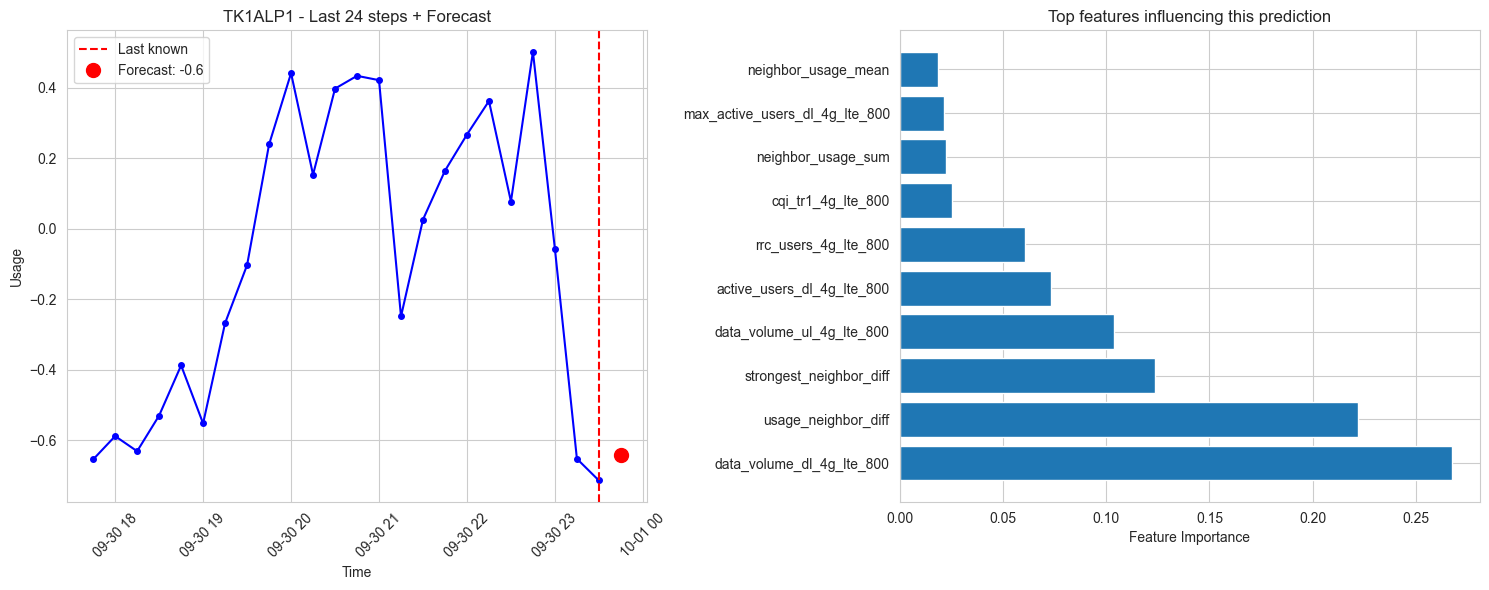

In [28]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# ---------- 24.1. НАСТРОЙКИ ----------
WINDOW_SIZE = 24  # 6 часов = 24 шага по 15 мин
PRED_HORIZON = 1  # 1 шаг вперёд (15 минут)
TARGET_CELL = "TK1ALP1"  # ← ИЗМЕНИ НА СВОЮ КЛЕТКУ

print(f" Predicting {PRED_HORIZON} step(s) ahead for cell '{TARGET_CELL}'")
print(f"   Using last {WINDOW_SIZE} steps ({WINDOW_SIZE*15//60} hours)")

# ---------- 24.2. ИЗВЛЕЧЕНИЕ ИСТОРИИ КЛЕТКИ ----------
def get_cell_history(df_kpi_grid, cell_name, n_steps=WINDOW_SIZE):
    """Последние n_steps наблюдений для клетки"""
    cell_data = df_kpi_grid[df_kpi_grid["cell"] == cell_name].copy()
    cell_data = cell_data.sort_values("start_time").tail(n_steps)

    if len(cell_data) < n_steps:
        print(f"Warning: only {len(cell_data)} steps available for {cell_name}")

    return cell_data

history = get_cell_history(df_kpi_grid, TARGET_CELL, WINDOW_SIZE)
print(f"History loaded: {len(history)} steps from {history['start_time'].min()} to {history['start_time'].max()}")

print("\nRecent history:")
print(history[["start_time", TARGET_COL, "neighbor_usage_mean", "rrc_users_4g_lte_800"]].tail())

# ---------- 24.3. ПОДГОТОВКА ФИЧ ДЛЯ ПРЕДСКАЗАНИЯ ----------
# Берём последние WINDOW_SIZE наблюдений
X_recent = history[INPUT_FEATURES].values[-WINDOW_SIZE:]  # shape: (WINDOW_SIZE, n_features)

# Последнее наблюдение → фичи для предсказания
X_forecast = X_recent[-1:]  # shape: (1, n_features)

# Масштабирование (используем тот же scaler, что обучен на train)
X_forecast_scaled = scaler.transform(X_forecast)

print(f"\nFeatures shape for prediction: {X_forecast.shape}")

# ---------- 24.4. ПРЕДСКАЗАНИЕ ----------
print("\nMaking prediction...")
y_forecast_scaled = rf_model.predict(X_forecast_scaled)  # rf_model из предыдущего блока

# Обратное масштабирование (приблизительно)
# Точный inverse нужен только если scaler обучен на TARGET тоже
y_forecast = y_forecast_scaled[0]

next_time = history["start_time"].max() + pd.Timedelta(minutes=15)
print(f"\n FORECAST:")
print(f"Cell: {TARGET_CELL}")
print(f"Next time: {next_time}")
print(f"Current usage: {history[TARGET_COL].iloc[-1]:.1f}")
print(f"PREDICTED usage: {y_forecast:.1f}")
print(f"Change: {y_forecast - history[TARGET_COL].iloc[-1]:+.1f} ({(y_forecast/history[TARGET_COL].iloc[-1]-1)*100:+.1f}%)")

# ---------- 24.5. ВИЗУАЛИЗАЦИЯ ----------
plt.figure(figsize=(15, 6))

# История
plt.subplot(1, 2, 1)
plt.plot(history["start_time"], history[TARGET_COL], 'b-', marker='o', markersize=4)
plt.axvline(history["start_time"].max(), color='r', linestyle='--', label='Last known')
plt.plot(next_time, y_forecast, 'ro', markersize=10, label=f'Forecast: {y_forecast:.1f}')
plt.xlabel("Time")
plt.ylabel("Usage")
plt.title(f"{TARGET_CELL} - Last {WINDOW_SIZE} steps + Forecast")
plt.legend()
plt.xticks(rotation=45)

# Важные фичи на последнем шаге
plt.subplot(1, 2, 2)
recent_importance = pd.DataFrame({
    "feature": INPUT_FEATURES,
    "value": X_forecast[0],
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True).tail(10)

plt.barh(range(10), recent_importance["importance"][-10:].values)
plt.yticks(range(10), recent_importance["feature"][-10:].values)
plt.xlabel("Feature Importance")
plt.title("Top features influencing this prediction")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Test data: 567360 samples (2025-08-31 23:45:00 → 2025-09-30 23:30:00)


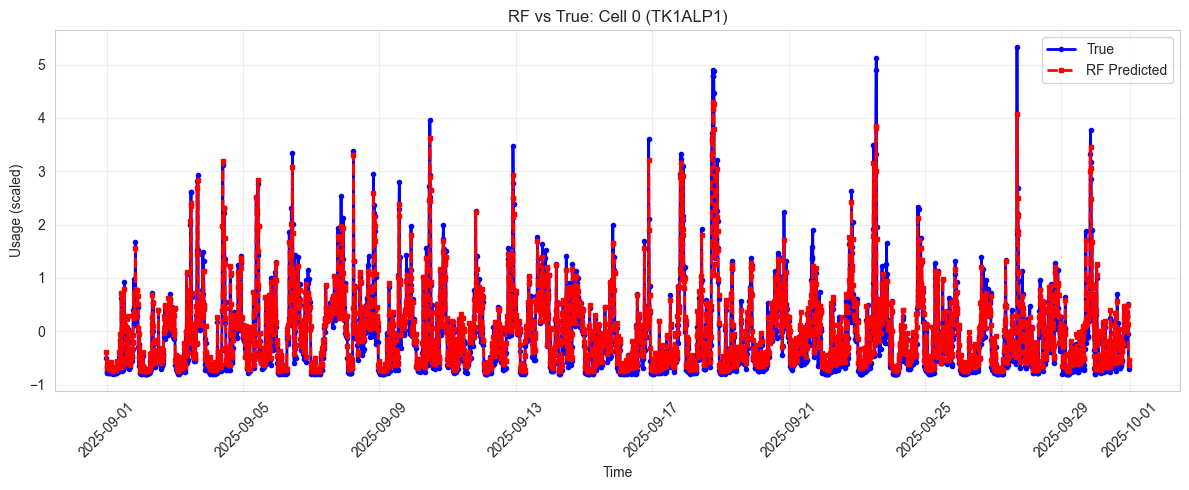


GLOBAL TEST METRICS:
MAE:   0.0622
RMSE:  0.1060
R²:    0.9895
SMAPE: 20.34%


In [41]:
# ---------- РАБОЧИЙ КОД ВИЗУАЛИЗАЦИИ ----------

# 1. Автоматическое определение test периода (последние ~15% данных)
n_total = len(df_kpi_grid["start_time"].unique())
test_size = max(432, int(n_total * 0.05))  # минимум 432 шага или 10%
test_times = sorted(df_kpi_grid["start_time"].tail(test_size * len(cells)).unique())

test_df = df_kpi_grid[df_kpi_grid["start_time"].isin(test_times)].copy()
print(f"Test data: {len(test_df)} samples ({test_df['start_time'].min()} → {test_df['start_time'].max()})")

# 2. Предсказания
test_df["rf_pred"] = rf_model.predict(scaler.transform(test_df[INPUT_FEATURES].values))

# 3. SMAPE вместо MAPE
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# 4. ТОЛЬКО ОДИН ГРАФИК (как ST-GNN)
def plot_cell_forecast(cell_id=0):
    """Визуализация для конкретной клетки"""
    cells_list = sorted(test_df["cell"].unique())
    cell_name = cells_list[cell_id]

    cell_data = test_df[test_df["cell"] == cell_name].sort_values("start_time")

    plt.figure(figsize=(12, 5))
    plt.plot(cell_data["start_time"], cell_data[TARGET_COL],
             'b-', linewidth=2, label="True", marker='o', markersize=3)
    plt.plot(cell_data["start_time"], cell_data["rf_pred"],
             'r--', linewidth=2, label="RF Predicted", marker='s', markersize=3)

    plt.xticks(rotation=45)
    plt.xlabel("Time")
    plt.ylabel("Usage (scaled)")
    plt.title(f"RF vs True: Cell {cell_id} ({cell_name})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ← ИЗМЕНИ НА СВОЮ КЛЕТКУ (0-N)
cell_id = 0
plot_cell_forecast(cell_id)

# 5. ГЛОБАЛЬНЫЕ МЕТРИКИ с SMAPE
error = np.abs(test_df[TARGET_COL] - test_df["rf_pred"])
print("\nGLOBAL TEST METRICS:")
print(f"MAE:   {error.mean():.4f}")
print(f"RMSE:  {np.sqrt((error**2).mean()):.4f}")
print(f"R²:    {r2_score(test_df[TARGET_COL], test_df['rf_pred']):.4f}")
print(f"SMAPE: {smape(test_df[TARGET_COL], test_df['rf_pred']):.2f}%")


5-day test period: 2025-09-25 23:30:00 → 2025-09-30 23:30:00


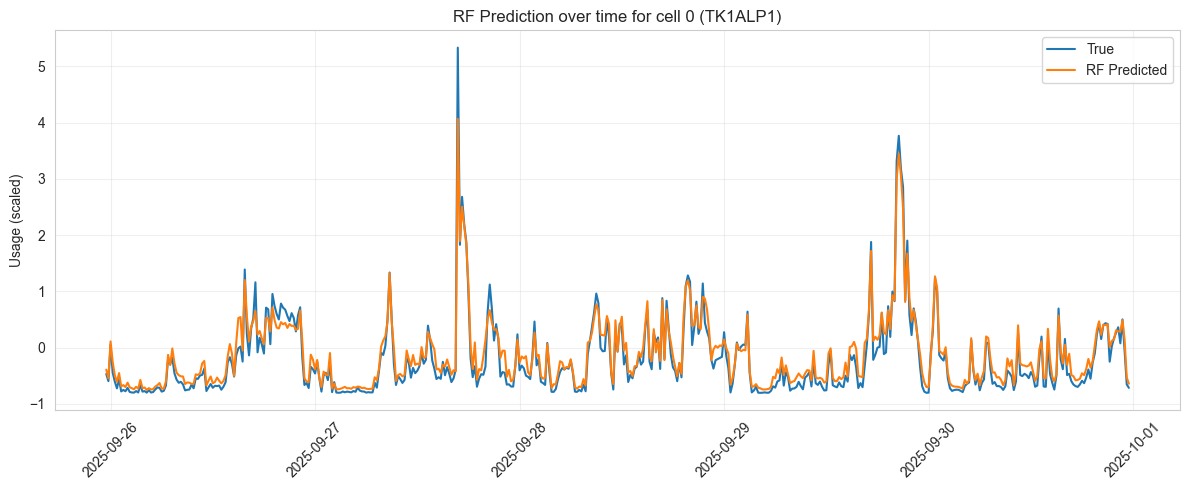

In [42]:
# ---------- RF predict_full_test ЭКВИВАЛЕНТ (5 дней) ----------

def rf_predict_full_test_5days():
    """Эквивалент ST-GNN predict_full_test, но ровно 5 дней"""

    # Берём последние 5 дней (5*24*4 = 480 шагов по 15 мин)
    end_time = df_kpi_grid["start_time"].max()
    start_time = end_time - pd.Timedelta(days=5)

    test_period = df_kpi_grid[
        (df_kpi_grid["start_time"] >= start_time) &
        (df_kpi_grid["start_time"] <= end_time)
    ].copy()

    # Предсказания RF
    test_period["rf_pred"] = rf_model.predict(
        scaler.transform(test_period[INPUT_FEATURES].values)
    )

    return test_period

# Использование (ТОЧНО как ST-GNN)
test_df_5d = rf_predict_full_test_5days()
print(f"5-day test period: {test_df_5d['start_time'].min()} → {test_df_5d['start_time'].max()}")

cell_id = 0  # выбери любую станцию
cells_list = sorted(test_df_5d["cell"].unique())
cell_name = cells_list[cell_id]

# Данные для выбранной клетки
cell_data = test_df_5d[test_df_5d["cell"] == cell_name].sort_values("start_time")
real_dates = cell_data["start_time"].values

plt.figure(figsize=(12,5))
plt.plot(real_dates, cell_data[TARGET_COL], label="True")
plt.plot(real_dates, cell_data["rf_pred"], label="RF Predicted")
plt.xticks(rotation=45)
plt.title(f"RF Prediction over time for cell {cell_id} ({cell_name})")
plt.legend()
plt.ylabel("Usage (scaled)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def regression_summary(y_true, y_pred):
    """Полный саммари регрессии"""
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "SMAPE (%)": smape,
        "MAPE": mape,
    }

# ---------- ПОЛНЫЙ АНАЛИЗ НА ВСЕХ ДАННЫХ ----------

# 1. Train + Val + Test = все доступные данные
full_df = df_kpi_grid.copy()
full_df["rf_pred"] = rf_model.predict(scaler.transform(full_df[INPUT_FEATURES].values))

# 2. Полные метрики
full_metrics = regression_summary(
    full_df[TARGET_COL].values,
    full_df["rf_pred"].values
)

print("FULL DATASET ANALYSIS (ALL SAMPLES)")
print("="*50)
for k, v in full_metrics.items():
    print(f"{k:10}: {v:.4f}")

print(f"\nTotal samples analyzed: {len(full_df):,}")
print(f"Time period: {full_df['start_time'].min()} → {full_df['start_time'].max()}")

# 3. Разбивка по сплитам (если есть train/val/test)
train_mask = df_kpi_grid["start_time"].isin(train_times)
val_mask = df_kpi_grid["start_time"].isin(val_times)
test_mask = df_kpi_grid["start_time"].isin(test_times)

splits_metrics = {}
for split_name, mask in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    split_data = full_df[mask]
    if len(split_data) > 0:
        splits_metrics[split_name] = regression_summary(
            split_data[TARGET_COL].values,
            split_data["rf_pred"].values
        )

# 4. Сравнительная таблица по сплитам
if splits_metrics:
    print("\nSPLITS COMPARISON:")
    print("-" * 50)
    comparison_table = pd.DataFrame(splits_metrics).round(4)
    print(comparison_table.T)



FULL DATASET ANALYSIS (ALL SAMPLES)
MSE       : 0.0112
MAE       : 0.0622
RMSE      : 0.1060
R2        : 0.9895
SMAPE (%) : 20.3377
MAPE      : 56.1583

Total samples analyzed: 567,360
Time period: 2025-08-31 23:45:00 → 2025-09-30 23:30:00

SPLITS COMPARISON:
--------------------------------------------------
          MSE     MAE    RMSE      R2  SMAPE (%)     MAPE
Train  0.0097  0.0586  0.0983  0.9903    19.8980  55.6527
Val    0.0155  0.0724  0.1244  0.9885    21.4759  62.6815
Test   0.0112  0.0622  0.1060  0.9895    20.3377  56.1583


Random Forest model dosiahla výsledky s R² = 0.9895, čo znamená, že vysvetľuje 98,95% variability dát o zaťažení siete.

RMSE 0,1060 potvrdzuje vysokú presnosť predikcií na všetkých vzorkoch.

Model vykazuje len mierne preučenie (RMSE Train 0,0983 vs Test 0,1060).
​